# **Atelier Préparation de Données Textuelles**

### **Contexte** 
Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client. 
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles. 

---
## **Partie 1 – Exploration du corpus**

### **1) Charger les données CSV**

In [257]:
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### **2) Combien d'avis contient le dataset ?**

In [258]:
print(f"Le dataset contient {len(df)} avis.")

Le dataset contient 1200 avis.


### **3) Combien de colonnes possède-t-il ?**

In [259]:
print(f"Le dataset possède {df.shape[1]} colonnes.")
print("Colonnes :", df.columns.tolist())

Le dataset possède 8 colonnes.
Colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### **4) Quel est le type de chaque colonne ?**

In [260]:
print(df.dtypes)

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


### **5) Existe-t-il des valeurs manquantes ?**

In [261]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nTotal de valeurs manquantes :", df.isnull().sum().sum())

Valeurs manquantes par colonne :
id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

Total de valeurs manquantes : 5


### **6) Identifier quelques types de texte**

In [262]:
# Texte normal
print("=== Texte normal ===")
print(df.loc[0, "texte"])

=== Texte normal ===
Très  bonne  expérience,  simple  et  efficace.


In [263]:
# Texte vide / NaN
print("\n=== Texte vide / NaN ===")
print(df[df["texte"].isna() | (df["texte"].astype(str).str.strip() == "")]["texte"].head(3))



=== Texte vide / NaN ===
46     NaN
108    NaN
310    NaN
Name: texte, dtype: str


In [264]:
# Texte contenant une URL
print("\n=== Texte avec URL ===")
print(df[df["texte"].astype(str).str.contains(r"https?://", na=False)]["texte"].head(2).tolist())



=== Texte avec URL ===
['Produit parfait, rien à signaler. https://example.com/commande/17', 'Très bonne expérience, simple et efficace. https://example.com/commande/31']


In [265]:
# Texte contenant une mention
print("\n=== Texte avec mention ===")
print(df[df["texte"].astype(str).str.contains(r"@\w+", na=False)]["texte"].head(2).tolist())


=== Texte avec mention ===
['@client Livraison rapide et produit conforme à mes attentes.', '@client Service client réactif et commande reçue rapidement.']


In [266]:
# Texte contenant un hashtag
print("\n=== Texte avec hashtag ===")
print(df[df["texte"].astype(str).str.contains(r"#\w+", na=False)]["texte"].head(2).tolist())



=== Texte avec hashtag ===
['Très satisfait de mon achat 👍 #avis', "La batterie tient vraiment bien et l'écran est superbe. #avis"]


In [267]:
# Texte contenant des emojis
print("\n=== Texte avec emojis ===")
print(df[df["texte"].astype(str).str.contains(r"[👍😊😡]", na=False)]["texte"].head(2).tolist())



=== Texte avec emojis ===
['Très satisfait de mon achat 👍 #avis', 'Très satisfait de mon achat 👍 😊']


In [268]:
# Texte avec beaucoup de ponctuation
print("\n=== Texte avec beaucoup de ponctuation ===")
print(df[df["texte"].astype(str).str.contains(r"!!!", na=False)]["texte"].head(2).tolist())



=== Texte avec beaucoup de ponctuation ===
['Produit excellent, je suis très satisfait. !!!', 'Très satisfait de mon achat 👍 !!!']


In [269]:
# Texte en majuscules
print("\n=== Texte en majuscules ===")
print(df[df["texte"].astype(str).str.isupper()]["texte"].head(2).tolist())



=== Texte en majuscules ===
["LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.", 'SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.']


In [270]:
# Texte avec répétition de caractères
print("\n=== Texte avec répétition de caractères ===")
print(df[df["texte"].astype(str).str.contains(r"(.)\1{2,}", na=False)]["texte"].head(2).tolist())


=== Texte avec répétition de caractères ===
['Produit excellent, je suis très satisfait. !!!', 'Très satisfait de mon achat 👍 !!!']


C:\Users\HP\AppData\Local\Temp\ipykernel_24172\1618673901.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  print(df[df["texte"].astype(str).str.contains(r"(.)\1{2,}", na=False)]["texte"].head(2).tolist())


### **7) Mesurer la longueur des textes**

In [271]:
# Remplacer les NaN par chaîne vide
df["texte"] = df["texte"].fillna("")

# Calculer la longueur en évitant les erreurs
df["longueur"] = df["texte"].astype(str).apply(lambda x: len(x.strip()))
print("Longueur minimale :", df["longueur"].min())
print("Longueur maximale :", df["longueur"].max())
print("Longueur moyenne  :", round(df["longueur"].mean(), 2))
print("Médiane           :", df["longueur"].median())
print("\nQuartiles :")
print(df["longueur"].quantile([0.25, 0.5, 0.75]))


Longueur minimale : 0
Longueur maximale : 635
Longueur moyenne  : 48.96
Médiane           : 48.0

Quartiles :
0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


### **8) Visualiser la distribution de la longueur des avis**

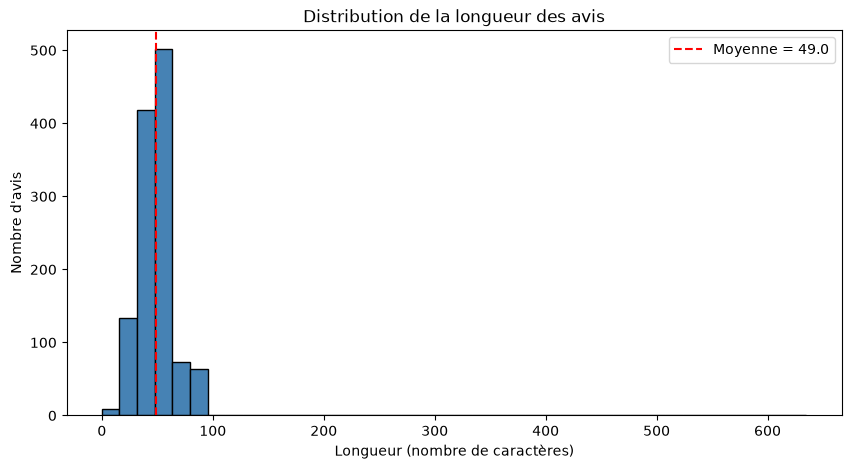

In [272]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["longueur"], bins=40, edgecolor="black", color="steelblue")
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (nombre de caractères)")
plt.ylabel("Nombre d'avis")
plt.axvline(df["longueur"].mean(), color="red", linestyle="--", label=f"Moyenne = {df['longueur'].mean():.1f}")
plt.legend()
plt.show()

### **Réponses aux questions :**

#### a) **Existe-t-il des textes anormalement longs ?**  
Oui, quelques textes dépassent largement la moyenne (plus de 100 caractères), mais dans l'ensemble les longueurs restent raisonnables pour des avis clients.

#### b) **Existe-t-il beaucoup de textes très courts ?**  
Oui, on observe une concentration de textes très courts (moins de 20-30 caractères), notamment des textes vides, des "OK" ou des messages très brefs.

### **9) Détecter les textes vides**

In [273]:
textes_vides = df[df["texte"].isna() | (df["texte"].astype(str).str.strip() == "")]
print(f"Nombre de textes vides ou NaN : {len(textes_vides)}")
textes_vides[["id_avis", "texte"]]

Nombre de textes vides ou NaN : 6


,id_avis,texte
46,AV0047,
108,AV0109,
310,AV0311,
640,AV0641,
781,AV0782,
951,AV0952,


### **10) Détecter les doublons sur le texte**

In [274]:
nb_doublons = df.duplicated(subset=["texte"]).sum()
print(f"Nombre de doublons exacts sur la colonne texte : {nb_doublons}")

# Afficher quelques exemples de textes qui apparaissent plusieurs fois
doublons = df[df.duplicated(subset=["texte"], keep=False)].groupby("texte").size().sort_values(ascending=False)
print("\nExemples de textes les plus répétés :")
doublons.head(10)

Nombre de doublons exacts sur la colonne texte : 881

Exemples de textes les plus répétés :


texte
Excellent rapport qualité-prix.                                  29
Livraison rapide et produit conforme à mes attentes.             19
Très satisfait de mon achat 👍                                    19
Très bon produit, la qualité est au rendez-vous.                 19
EXCELLENT RAPPORT QUALITÉ-PRIX.                                  16
Je viens de recevoir le produit, à voir dans le temps.           16
@client Service client réactif et commande reçue rapidement.     16
LIVRAISON RAPIDE ET PRODUIT CONFORME À MES ATTENTES.             16
La batterie tient vraiment bien et l'écran est superbe. #avis    15
Très bonne expérience, simple et efficace.                       15
dtype: int64

### **11) Les classes sont-elles équilibrées ?**

In [275]:
print(df["sentiment"].value_counts())
print("\nRépartition en pourcentage :")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

Répartition en pourcentage :
sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64


#### **Réponse :** 
Non, les classes ne sont pas équilibrées. La classe `positif` domine largement.

### **12) Quelle est la classe majoritaire ?**

In [276]:
classe_maj = df["sentiment"].value_counts().idxmax()
print(f"La classe majoritaire est : {classe_maj}")

La classe majoritaire est : positif


### **13) Quelles métriques de classification à envisager d'utiliser ?**

Comme les classes sont déséquilibrées, l'**accuracy** seule n'est pas suffisante.  
On privilégiera :
- **F1-score** (macro ou weighted)
- **Precision** et **Recall** par classe
- **Matrice de confusion**
- Éventuellement **balanced accuracy**

### **14) Détecter les caractères particuliers**

In [277]:
from email.mime import text
import re
motifs = {
    "emojis": r'[\U0001F300-\U0001FAFF\u2600-\u27BF]',
    "URLs": r'https?://\S+',
    "hashtags": r'#\w+',
    "mentions": r'@\w+',
    "chiffres": r'\d',
    "caractères spéciaux (hors lettres/accents/espaces)": r'[^\w\sÀ-ÿ]',
    "ponctuation répétée (!!, ??, ...)": r'([!?.,])\1{1,}',
}

textes = df["texte"].astype(str)

for nom, motif in motifs.items():
    n_occurrences = textes.apply(lambda t: len(re.findall(motif, t))).sum()
    n_avis_concernes = textes.apply(lambda t: bool(re.search(motif, t))).sum()
    print(f"{nom:55s} -> {n_occurrences:4d} occurrences dans {n_avis_concernes:4d} avis")


emojis                                                  ->  205 occurrences dans  192 avis
URLs                                                    ->  143 occurrences dans  143 avis
hashtags                                                ->  127 occurrences dans  127 avis
mentions                                                ->  128 occurrences dans  128 avis
chiffres                                                ->  441 occurrences dans  142 avis
caractères spéciaux (hors lettres/accents/espaces)      -> 3709 occurrences dans 1190 avis
ponctuation répétée (!!, ??, ...)                       ->  141 occurrences dans  141 avis


### **15) Visualiser et commenter le nombre d'avis par source**

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


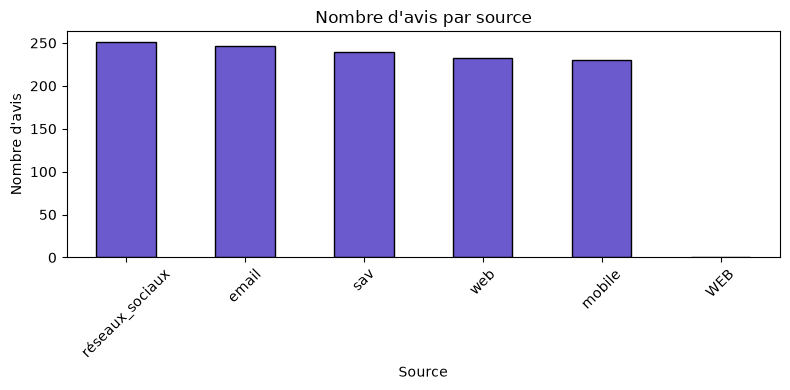

In [278]:
counts_source = df["source"].value_counts()
print(counts_source)

plt.figure(figsize=(8, 4))
counts_source.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<mark style= "background-color: lightblue">**💬Commentaire:**</mark>

Les 5 sources (**web**, **mobile**, **réseaux_sociaux**, **sav** et **email**) sont relativement bien réparties, avec environ 230 à 250 avis par source. On remarque toutefois la présence de **WEB** en majuscules, en plus de **web**. Il s’agit d’une différence d’écriture pour désigner la même source. Cette incohérence devra être corrigée lors du nettoyage des données afin d’harmoniser les valeurs.



### **16) Visualiser et commenter le nombre d'avis par produit**

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


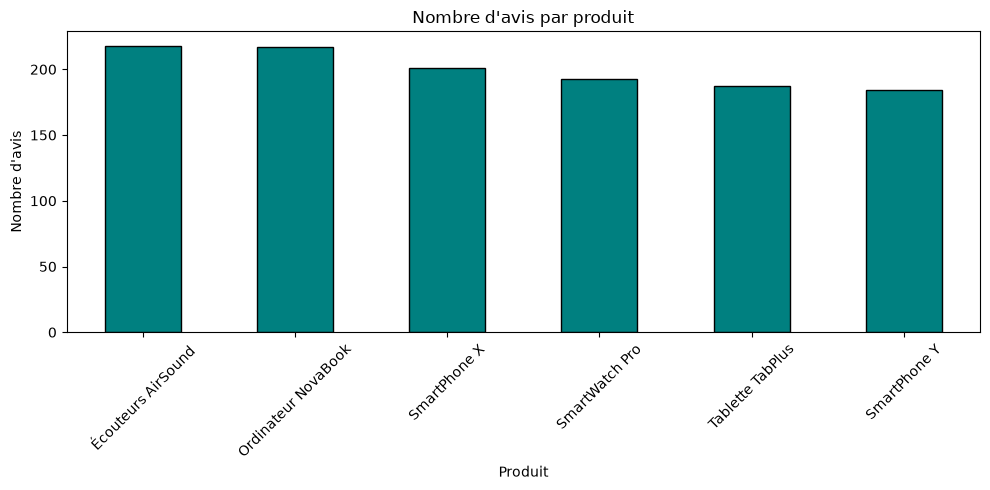

In [279]:
counts_produit = df["produit"].value_counts()
print(counts_produit)

plt.figure(figsize=(10, 5))
counts_produit.plot(kind="bar", color="teal", edgecolor="black")
plt.title("Nombre d'avis par produit")
plt.xlabel("Produit")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 <mark style= "background-color: lightblue">**💬Commentaire:**</mark>

Les 6 produits sont représentés de façon relativement homogène (entre 184 et
218 avis), avec un léger surplus pour les Écouteurs AirSound et l'Ordinateur NovaBook. Pas de
produit sous-représenté au point de poser un problème pour l'analyse.


---
## **Partie 2 – Nettoyage**

### **1) Supprimer les lignes contenant des valeurs manquantes de texte**
On supprime aussi les textes qui ne sont pas `NaN` mais qui sont vides après avoir retiré les
espaces (Partie 1, Q9), car ils sont tout aussi inexploitables

In [280]:
df_clean = df.drop(columns=['longueur']).copy()  # on repart d'une copie propre

avant = len(df_clean)
print(f"Lignes avant nettoyage : {avant}")
df_clean = df_clean.dropna(subset=['texte'])
df_clean = df_clean[df_clean['texte'].str.strip() != '']
print(f"Lignes supprimées (texte manquant/vide) : {avant - len(df_clean)}")
print(f"Lignes restantes : {len(df_clean)}")





Lignes avant nettoyage : 1200
Lignes supprimées (texte manquant/vide) : 6
Lignes restantes : 1194


### **2) Supprimer les doublons**

In [281]:
avant = len(df_clean)
print(f"Lignes avant suppression des doublons : {avant}")
df_clean = df_clean.drop_duplicates(subset= 'texte', keep='first')
print(f"Doublons supprimés : {avant - len(df_clean)}")
print(f"Lignes restantes   : {len(df_clean)}")


Lignes avant suppression des doublons : 1194
Doublons supprimés : 877
Lignes restantes   : 317


On profite aussi de cette étape pour harmoniser deux colonnes catégorielles repérées en
exploration (source avec **WEB/web**, **langue** avec **FR/fr**) : ce n'est pas du texte libre
mais c'est un même problème de cohérence de saisie.


In [282]:
df_clean['source'] = df_clean['source'].str.lower()
df_clean['langue'] = df_clean['langue'].str.lower()
df_clean['source'].value_counts()


source
sav                72
réseaux_sociaux    71
web                63
mobile             56
email              55
Name: count, dtype: int64

### **3) Supprimer les URLs**

In [283]:
df["texte"] = df["texte"].astype(str).str.replace(r"https?://\S+", " ", regex=True)

### **4) Traiter les mentions et hashtags**

**Stratégie choisie pour la classification de sentiment :**  
- On **supprime** les mentions (`@...`) car elles n'apportent pas d'information de sentiment.  
- On **garde le mot** des hashtags (on enlève seulement le `#`) car un hashtag comme `#avis` ou `#déception` peut contenir un signal de sentiment.



- **Suppression des mentions**

In [284]:

df["texte"] = df["texte"].str.replace(r"@\w+", " ", regex=True)



- **Gestion des hashtags**

In [285]:

df["texte"] = df["texte"].str.replace(r"#(\w+)", r"\1", regex=True)

### **5) Nettoyer les espaces**

In [286]:
df["texte"] = df["texte"].str.replace(r"\s+", " ", regex=True).str.strip()

### **6) Traiter la ponctuation**

 ### <mark style= "background-color: lightblue">**👁️‍🗨️Stratégie:**</mark>



Pour une classification de sentiment, toute la ponctuation n'a pas la même valeur informative.
Les virgules et points simples sont purement grammaticaux et n'apportent aucun signal de
sentiment — les supprimer réduit le bruit sans perte d'information utile. En revanche, `!` et
`?` portent une réelle charge émotionnelle (intensité, insistance, surprise) et méritent d'être
conservés.

La stratégie retenue se fait en deux temps : (1) réduire d'abord les répétitions de `!`, `?` et
`.` à une seule occurrence (`!!!` → `!`), pour garder le signal "ponctuation forte présente"
sans donner un poids disproportionné aux avis qui répètent simplement plus de fois le même
caractère ; (2) supprimer ensuite tout le reste de la ponctuation, en conservant `!` et `?`.
L'ordre de ces deux étapes est important : réduire avant de supprimer évite que `!!!` ne
disparaisse complètement au lieu d'être ramené à `!`.

Sur ce dataset, 141 avis sur 1195 (≈ 11,8 %) contiennent de la ponctuation répétée — uniquement
des `!` (ni `?` ni `...` n'apparaissent dans ce corpus). Ce traitement concerne donc une part non
négligeable des avis, notamment ceux exprimant une émotion marquée (forte satisfaction ou fort
mécontentement).

In [287]:
import string

# supprimer les lignes sans texte (avant tout le reste)
df = df.dropna(subset=["texte"]).reset_index(drop=True)

#  réduire les répétitions de !, ? et . à une seule occurrence
df["texte_clean"] = df["texte"].str.replace(r"!{2,}", "!", regex=True)
df["texte_clean"] = df["texte_clean"].str.replace(r"\?{2,}", "?", regex=True)
df["texte_clean"] = df["texte_clean"].str.replace(r"\.{2,}", ".", regex=True)

#  supprimer le reste de la ponctuation, en gardant ! et ? (porteurs de sentiment)
ponctuation_a_supprimer = string.punctuation.replace("!", "").replace("?", "")
df["texte_clean"] = df["texte_clean"].str.translate(str.maketrans("", "", ponctuation_a_supprimer))

#  nettoyer les espaces multiples laissés par les suppressions
df["texte_clean"] = df["texte_clean"].str.replace(r"\s+", " ", regex=True).str.strip()

### **7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus**

In [288]:
import re
import string
import pandas as pd


# === Question 7 : Créer la fonction de nettoyage ===
import re
import string
import pandas as pd

def nettoyer_texte(texte):
    if pd.isna(texte):
        return ""
    texte = str(texte)
    
    # Supprimer les URLs
    texte = re.sub(r"https?://\S+", " ", texte)
    
    # Traiter les mentions et hashtags
    texte = re.sub(r"@\w+", " ", texte)
    texte = re.sub(r"#(\w+)", r"\1", texte)
    
    # Traiter la ponctuation
    texte = re.sub(r"!{2,}", "!", texte)
    texte = re.sub(r"\?{2,}", "?", texte)
    texte = re.sub(r"\.{2,}", ".", texte)
    
    # (optionnel) enlever le reste de la ponctuation sauf ! et ?
    ponctuation_a_supprimer = string.punctuation.replace("!", "").replace("?", "")
    texte = texte.translate(str.maketrans("", "", ponctuation_a_supprimer))
    
    # Nettoyer les espaces
    texte = re.sub(r"\s+", " ", texte).strip()
    
    return texte

### **8) Stocker sur une colonne texte_clean**

In [289]:

df_clean["texte_clean"] = df_clean["texte"].apply(nettoyer_texte)

print("Colonne texte_clean créée.")
print(f"Nombre de lignes : {len(df)}")


Colonne texte_clean créée.
Nombre de lignes : 1200


### **9) Vérifier `texte` vs `texte_clean` sur les 10 premières observations**

In [290]:
df[['texte', 'texte_clean']].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait !
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET LÉCRAN EST ...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat 👍
8,Le produit correspond globalement à la descrip...,Le produit correspond globalement à la descrip...
9,Livraison rapide et produit conforme à mes att...,Livraison rapide et produit conforme à mes att...


---
# **Partie 3: Tokenisation**

### **1) Pourquoi `split()` n'est-il pas suffisant pour une vraie application NLP ?**


`split()` a l’air simple et efficace… jusqu’au moment où tu regardes vraiment ce qu’il produit sur des avis clients.  

Prends la phrase :  
 <mark style= "background-color: lightblue">**« L’écran est superbe!!! Mais la batterie… 😤 »**</mark>

Avec un simple `split()`, tu obtiens des tokens comme `"superbe!!!"`, `"batterie…"`, `"😤"`. Le modèle va alors considérer `"superbe!!!"` et `"superbe"` comme deux mots complètement différents. Pareil pour `"l’écran"` qui reste collé, ou pour les points de suspension et les emojis qui viennent polluer le vocabulaire.  

En clair, `split()` ne « comprend » pas où s’arrête un mot. Il se contente de couper là où il y a un espace. Pour un vrai travail de classification de sentiment, on a besoin d’un tokenizer qui sait séparer la ponctuation, gérer les apostrophes françaises et isoler proprement les emojis. Sinon on entraîne le modèle sur du bruit.

### **2) Tokenisation avec NLTK**

In [291]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import word_tokenize 

### **a) le nombre de tokens de chaque texte**

In [292]:
df_clean["tokens"] = df_clean["texte_clean"].apply(
    lambda t: word_tokenize(t, language="french")
)

df_clean["n_tokens"] = df_clean["tokens"].apply(len)

df_clean[["texte_clean", "tokens", "n_tokens"]].head(10)



,texte_clean,tokens,n_tokens
0,Très bonne expérience simple et efficace,"[Très, bonne, expérience, simple, et, efficace]",6
1,Très satisfait de mon achat 👍 avis,"[Très, satisfait, de, mon, achat, 👍, avis]",7
2,Produit parfait rien à signaler,"[Produit, parfait, rien, à, signaler]",5
3,Produit excellent je suis très satisfait !,"[Produit, excellent, je, suis, très, satisfait...",7
4,LA BATTERIE TIENT VRAIMENT BIEN ET LÉCRAN EST ...,"[LA, BATTERIE, TIENT, VRAIMENT, BIEN, ET, LÉCR...",9
5,Très satisfait de mon achat 👍 😊,"[Très, satisfait, de, mon, achat, 👍, 😊]",7
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,"[SERVICE, CLIENT, RÉACTIF, ET, COMMANDE, REÇUE...",7
7,Très satisfait de mon achat 👍,"[Très, satisfait, de, mon, achat, 👍]",6
8,Le produit correspond globalement à la descrip...,"[Le, produit, correspond, globalement, à, la, ...",7
9,Livraison rapide et produit conforme à mes att...,"[Livraison, rapide, et, produit, conforme, à, ...",8


### **b) nombre moyen de tokens**

In [293]:
moyenne_tokens = df_clean["n_tokens"].mean()

print("Nombre moyen de tokens par avis :", round(moyenne_tokens, 2))

Nombre moyen de tokens par avis : 6.94


### **c) texte avec le plus grand nombre de tokens** 

In [294]:
idx_max = df_clean["n_tokens"].idxmax()

print("Texte avec le plus grand nombre de tokens :")
print("Nombre de tokens :", df_clean.loc[idx_max, "n_tokens"])
print("Texte :", df_clean.loc[idx_max, "texte_clean"])

Texte avec le plus grand nombre de tokens :
Nombre de tokens : 120
Texte : Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue
